# LOAN DATA ANALYSIS WITH PYTHON
## Purpose:
- This notebook loads the loan dataset, explores the data,
- cleans missing values, converts categories where needed,
- and builds a simple model to predict Loan_Status.

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression



In [2]:

# LOAD THE DATASET
df = pd.read_csv("loanP_train.csv")

# DISPLAY BASIC INFORMATION

print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())



First 5 rows:
  Loan_ID Gender Marital_Status Dependents Graduate Self_Employed  \
0  LI0100   Male         Single          0      Yes            No   
1  LI0101   Male        Married          1      Yes            No   
2  LI0102   Male        Married          0      Yes           Yes   
3  LI0103   Male        Married          0       No            No   
4  LI0104   Male         Single          0      Yes            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

In [3]:
print(df.dtypes)

Loan_ID                  str
Gender                   str
Marital_Status           str
Dependents               str
Graduate                 str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [4]:
# CHECK THE SHAPE OF THE DATASET
print("\nDataset shape:")
print(df.shape)

# DESCRIBE NUMERICAL COLUMNS
print("\nSummary statistics:")
print(df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
          "Loan_Amount_Term", "Credit_History"]].describe())

# HANDLE MISSING VALUES

# Fill missing values in categorical columns using mode
categorical_cols = [
    "Loan_ID", "Gender", "Marital_Status", "Dependents",
    "Graduate", "Self_Employed", "Property_Area", "Loan_Status"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill missing values in numerical columns using median
numerical_cols = [
    "ApplicantIncome", "CoapplicantIncome", "LoanAmount",
    "Loan_Amount_Term", "Credit_History"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after filling:")
print(df.isnull().sum())

# CHECK FOR DUPLICATES
print("\nNumber of duplicate rows before removing:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Number of duplicate rows after removing:")
print(df.duplicated().sum())


Dataset shape:
(599, 13)

Summary statistics:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       599.000000         599.000000  578.000000        585.000000   
mean       5420.687813        1563.913055  145.434256        342.461538   
std        6169.168633        2456.618360   84.596463         64.868352   
min         150.000000           0.000000    9.000000         12.000000   
25%        2874.000000           0.000000  100.000000        360.000000   
50%        3812.000000        1210.000000  126.500000        360.000000   
75%        5807.500000        2279.000000  165.000000        360.000000   
max       81000.000000       33837.000000  700.000000        480.000000   

       Credit_History  
count       550.00000  
mean          0.84000  
std           0.36694  
min           0.00000  
25%           1.00000  
50%           1.00000  
75%           1.00000  
max           1.00000  

Missing values after filling:
Loan_ID              0
Gender 


Loan Status counts:
Loan_Status
Y    410
N    189
Name: count, dtype: int64


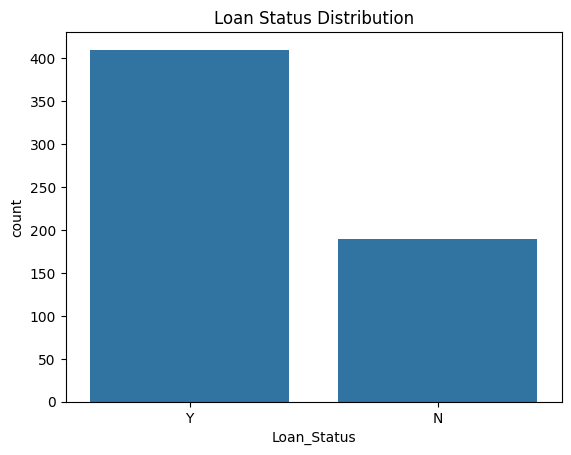

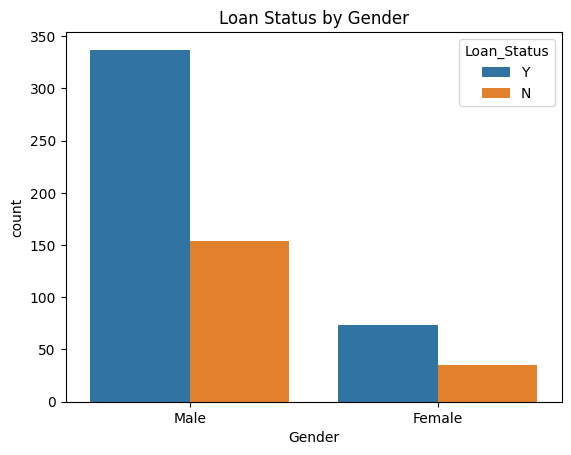

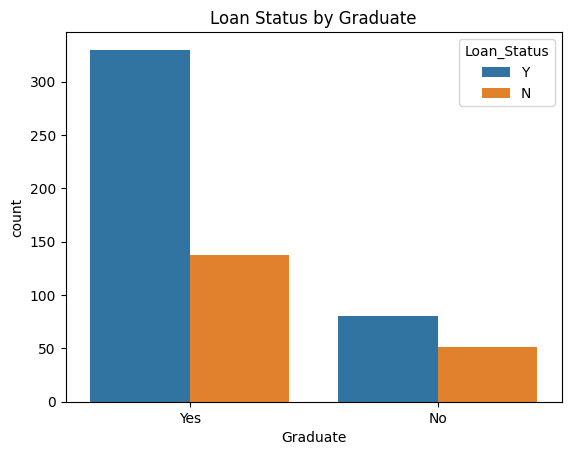

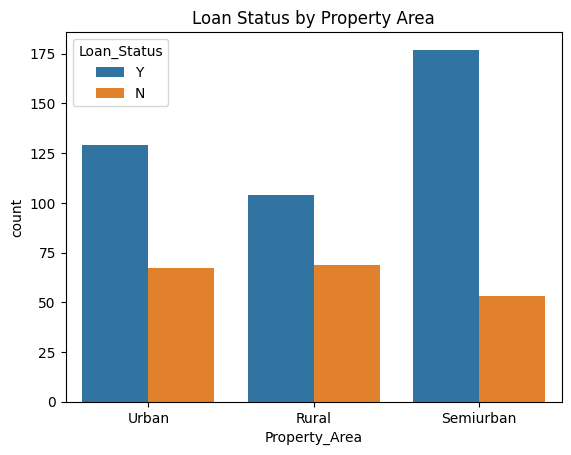

In [5]:

# EXPLORE TARGET VARIABLE

print("\nLoan Status counts:")
print(df["Loan_Status"].value_counts())

sns.countplot(x="Loan_Status", data=df)
plt.title("Loan Status Distribution")
plt.show()

# VISUALIZE SOME IMPORTANT FEATURES

sns.countplot(x="Gender", hue="Loan_Status", data=df)
plt.title("Loan Status by Gender")
plt.show()

sns.countplot(x="Graduate", hue="Loan_Status", data=df)
plt.title("Loan Status by Graduate")
plt.show()

sns.countplot(x="Property_Area", hue="Loan_Status", data=df)
plt.title("Loan Status by Property Area")
plt.show()




Encoded dataset preview:
   Gender  Marital_Status  Dependents  Graduate  Self_Employed  \
0       1               1           0         1              0   
1       1               0           1         1              0   
2       1               0           0         1              1   
3       1               0           0         0              0   
4       1               1           0         1              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       126.5             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Property_Area  Loan_Status  
0             1.0              2            1  
1             1.0              0            0  
2     

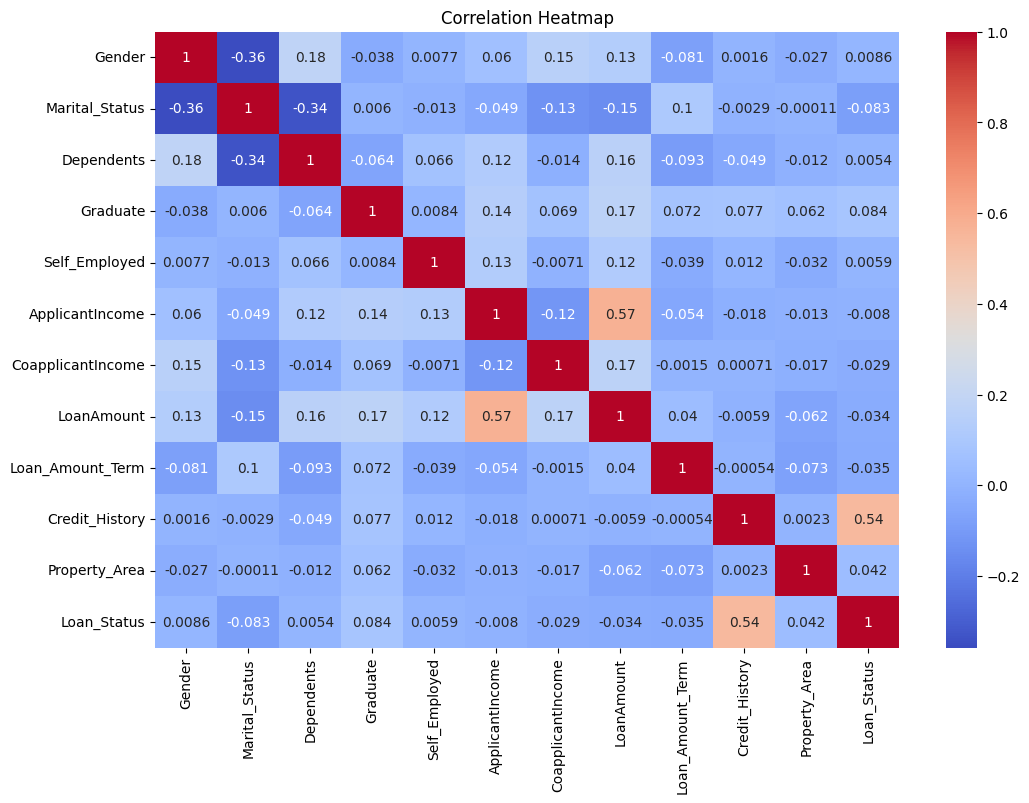

In [6]:

# DROP Loan_ID because it is only an identifier and not useful for analysis/modeling
df = df.drop("Loan_ID", axis=1)
# ENCODE CATEGORICAL COLUMNS USING LABELENCODER
label_encoder = LabelEncoder()

categorical_cols = [
    "Gender",
    "Marital_Status",
    "Dependents",
    "Graduate",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded dataset preview:")
print(df.head())



# VIEW CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             599 non-null    int64  
 1   Marital_Status     599 non-null    int64  
 2   Dependents         599 non-null    int64  
 3   Graduate           599 non-null    int64  
 4   Self_Employed      599 non-null    int64  
 5   ApplicantIncome    599 non-null    int64  
 6   CoapplicantIncome  599 non-null    float64
 7   LoanAmount         599 non-null    float64
 8   Loan_Amount_Term   599 non-null    float64
 9   Credit_History     599 non-null    float64
 10  Property_Area      599 non-null    int64  
 11  Loan_Status        599 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 56.3 KB


In [8]:

# DEFINE FEATURES AND TARGET

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


# SPLIT THE DATA

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)





Training set shape: (479, 11)
Testing set shape: (120, 11)


In [9]:

# TRAIN A MACHINE LEARNING MODEL

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# MAKE PREDICTIONS

y_pred = model.predict(X_test)

# 16. EVALUATE THE MODEL

print("\nModel Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Model Accuracy:
0.7416666666666667

Confusion Matrix:
[[17 29]
 [ 2 72]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.37      0.52        46
           1       0.71      0.97      0.82        74

    accuracy                           0.74       120
   macro avg       0.80      0.67      0.67       120
weighted avg       0.78      0.74      0.71       120



c:\Users\Harold David\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:

# SAVE THE CLEANED DATASET
df.to_csv("loan_data_cleaned.csv", index=False)

print("\nCleaned dataset saved successfully as loan_data_cleaned.csv")


Cleaned dataset saved successfully as loan_data_cleaned.csv
